# Comparación de modelos — Riesgo de retraso en el pago

## Objetivo del notebook

El objetivo de este notebook es comparar la regresión logística seleccionada como baseline con algoritmos de mayor complejidad y determinar si existe una mejora predictiva suficientemente relevante como para justificar una menor interpretabilidad.

La comparación utilizará exclusivamente las 34 features del **Modelo C**, formado por:

- características de la factura actual;
- contexto temporal;
- histórico comercial del cliente;
- comportamiento histórico de pago;
- comportamiento reciente;
- variables relativas al importe;
- indicadores de disponibilidad de histórico.

No se utilizarán las variables adicionales de exposición del Modelo D, ya que durante la ablación aportaron una mejora mínima respecto al Modelo C.

## Modelos a comparar

Se utilizarán inicialmente cuatro algoritmos:

1. **Logistic Regression**
   - baseline supervisado;
   - modelo lineal e interpretable.

2. **Random Forest**
   - modelo basado en múltiples árboles;
   - permite capturar relaciones no lineales e interacciones.

3. **Gradient Boosting**
   - árboles construidos secuencialmente para corregir errores anteriores;
   - puede capturar patrones más complejos que la regresión logística.

4. **HistGradientBoosting**
   - variante eficiente de Gradient Boosting;
   - adecuada para relaciones no lineales y datasets tabulares.

En esta fase no se realizará todavía optimización de hiperparámetros.

El objetivo es comparar el comportamiento inicial de diferentes familias de modelos utilizando condiciones equivalentes.

## Metodología

Se mantendrá exactamente el mismo split temporal utilizado anteriormente:

- train: período más antiguo;
- validation: período posterior utilizado para comparación;
- test: período más reciente, completamente reservado.

El conjunto de test no se utilizará para:

- seleccionar algoritmo;
- ajustar hiperparámetros;
- seleccionar features;
- seleccionar threshold.

## Métricas principales

Para comparar algoritmos se dará prioridad a métricas independientes del threshold:

- **PR-AUC**, especialmente relevante para la clase positiva;
- **ROC-AUC**, como medida complementaria de discriminación.

También se observarán:

- Precision;
- Recall;
- F1;
- F2;
- Balanced Accuracy.

Las métricas dependientes del threshold se calcularán inicialmente con `threshold = 0.50`.

El threshold se optimizará únicamente después de seleccionar los modelos candidatos.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
)

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

In [2]:
PROJECT_ROOT = Path("..")

GOLD_DIR = (
    PROJECT_ROOT
    / "data"
    / "gold"
)

GOLD_FILE = (
    GOLD_DIR
    / "gold_invoice_risk.parquet"
)

print(
    GOLD_FILE.resolve()
)

C:\Users\jesus\OneDrive\Documents\Evolve Data Science\portfolio\sistema_predictivo_tesoreria_y_riesgo_de_impago\data\gold\gold_invoice_risk.parquet


In [3]:
df = pd.read_parquet(
    GOLD_FILE
)

print(
    f"Filas: {df.shape[0]:,}"
)

print(
    f"Columnas: {df.shape[1]}"
)

display(
    df.head()
)

Filas: 2,466
Columnas: 48


,invoice_id,customer_id,invoice_date,due_date,invoice_amount,log_invoice_amount,paperless_bill,country_code,invoice_year,invoice_month,...,amount_diff_vs_previous_avg,open_amount_vs_current_invoice,overdue_amount_vs_current_invoice,is_new_customer,has_payment_history,has_3_payment_history,has_5_payment_history,has_open_invoices,has_overdue_invoices,late_payment
0,280670965,3993-QUNVJ,2012-01-03,2012-02-02,50.39,3.939444,PAPER,770,2012,1,...,NaN,0.0,0.0,1,0,0,0,0,0,0
1,5133177585,6708-DPYTF,2012-01-03,2012-02-02,55.37,4.031937,PAPER,391,2012,1,...,NaN,0.0,0.0,1,0,0,0,0,0,1
2,5928070131,1604-LIFKX,2012-01-03,2012-02-02,97.60,4.591071,PAPER,818,2012,1,...,NaN,0.0,0.0,1,0,0,0,0,0,1
3,6050714721,8887-NCUZC,2012-01-03,2012-02-02,15.99,2.832625,PAPER,818,2012,1,...,NaN,0.0,0.0,1,0,0,0,0,0,1
4,6393629835,5164-VMYWJ,2012-01-03,2012-02-02,71.33,4.281239,PAPER,406,2012,1,...,NaN,0.0,0.0,1,0,0,0,0,0,0


## 1. Validación del dataset

La comparación de modelos partirá exactamente del mismo dataset Gold utilizado durante las fases de baseline e interpretabilidad.

Antes de entrenar los modelos se comprobará que:

- existen 2.466 facturas;
- `invoice_id` continúa siendo único;
- la variable objetivo no contiene valores ausentes;
- se mantienen los 877 casos positivos;
- la tasa global de retraso continúa siendo aproximadamente del 35,6 %.

Esto garantiza que las diferencias observadas entre modelos no se deben a cambios accidentales en los datos.

### Checks

In [4]:
checks = pd.Series({
    "rows": len(df),

    "columns": df.shape[1],

    "duplicated_invoice_id": (
        df["invoice_id"]
        .duplicated()
        .sum()
    ),

    "missing_invoice_date": (
        df["invoice_date"]
        .isna()
        .sum()
    ),

    "missing_target": (
        df["late_payment"]
        .isna()
        .sum()
    ),

    "positive_cases": (
        df["late_payment"]
        .sum()
    ),

    "positive_rate_pct": (
        df["late_payment"]
        .mean()
        * 100
    ),
})

display(checks)

assert len(df) == 2466

assert df["invoice_id"].is_unique

assert df["invoice_date"].notna().all()

assert df["late_payment"].notna().all()

assert (
    df["late_payment"].sum()
    == 877
)

print(
    "✓ Dataset Gold validado."
)

rows                     2466.000000
columns                    48.000000
duplicated_invoice_id       0.000000
missing_invoice_date        0.000000
missing_target              0.000000
positive_cases            877.000000
positive_rate_pct          35.563666
dtype: float64

✓ Dataset Gold validado.


### Definir las features

In [5]:
invoice_features = [
    "invoice_amount",
    "log_invoice_amount",
    "paperless_bill",
    "country_code",
]

temporal_features = [
    "invoice_year",
    "invoice_month",
    "invoice_quarter",
    "invoice_weekday",
    "is_month_start",
    "is_month_end",
    "days_since_dataset_start",
]

customer_history_features = [
    # Histórico comercial
    "previous_issued_count",
    "previous_avg_invoice_amount",
    "previous_median_invoice_amount",
    "days_since_previous_invoice",

    # Histórico de pagos conocido
    "previous_settled_count",
    "previous_late_count",
    "previous_late_rate",
    "previous_avg_delay",
    "previous_median_delay",
    "previous_max_delay",
    "last_payment_delay",
    "days_since_last_payment",

    # Comportamiento reciente
    "last_3_late_rate",
    "last_3_avg_delay",
    "last_5_late_rate",
    "last_5_avg_delay",

    # Importe relativo
    "amount_vs_previous_avg",
    "amount_vs_previous_median",
    "amount_diff_vs_previous_avg",

    # Disponibilidad de histórico
    "is_new_customer",
    "has_payment_history",
    "has_3_payment_history",
    "has_5_payment_history",
]

model_features = (
    invoice_features
    + temporal_features
    + customer_history_features
)

assert len(model_features) == 34

print(
    f"Features utilizadas: "
    f"{len(model_features)}"
)

Features utilizadas: 34


### Definir categoricas

In [6]:
categorical_features = [
    "paperless_bill",
    "country_code",
    "invoice_month",
    "invoice_quarter",
    "invoice_weekday",
]

numeric_features = [
    col
    for col in model_features
    if col not in categorical_features
]

print(
    f"Numéricas: {len(numeric_features)}"
)

print(
    f"Categóricas originales: "
    f"{len(categorical_features)}"
)

Numéricas: 29
Categóricas originales: 5


## 2. División temporal

Se reconstruirá exactamente la misma división temporal utilizada en los notebooks anteriores.

Las fechas únicas se dividirán aproximadamente en:

- 70 % para train;
- 15 % para validation;
- 15 % para test.

Las facturas emitidas el mismo día permanecerán dentro del mismo conjunto.

Durante este notebook únicamente se utilizarán train y validation.

El conjunto de test se conservará completamente aislado para la evaluación final del proyecto.

### Reconstruir split

In [7]:
unique_dates = np.sort(
    df["invoice_date"]
    .dropna()
    .unique()
)

train_cut_index = int(
    len(unique_dates) * 0.70
)

validation_cut_index = int(
    len(unique_dates) * 0.85
)

train_cutoff = (
    unique_dates[
        train_cut_index
    ]
)

validation_cutoff = (
    unique_dates[
        validation_cut_index
    ]
)

train_df = df[
    df["invoice_date"]
    < train_cutoff
].copy()

validation_df = df[
    (
        df["invoice_date"]
        >= train_cutoff
    )
    &
    (
        df["invoice_date"]
        < validation_cutoff
    )
].copy()

test_df = df[
    df["invoice_date"]
    >= validation_cutoff
].copy()

### Resumen split

In [8]:
split_summary = []

for name, subset in {
    "train": train_df,
    "validation": validation_df,
    "test": test_df,
}.items():

    split_summary.append({
        "dataset": name,
        "rows": len(subset),

        "start_date": (
            subset["invoice_date"]
            .min()
        ),

        "end_date": (
            subset["invoice_date"]
            .max()
        ),

        "positive_cases": (
            subset["late_payment"]
            .sum()
        ),

        "positive_rate": (
            subset["late_payment"]
            .mean()
        ),
    })

split_summary = pd.DataFrame(
    split_summary
)

split_summary

,dataset,rows,start_date,end_date,positive_cases,positive_rate
0,train,1719,2012-01-03,2013-05-04,656,0.381617
1,validation,381,2013-05-05,2013-08-19,124,0.325459
2,test,366,2013-08-20,2013-12-02,97,0.265027


### `X` e `y`

In [9]:
X_train = (
    train_df[
        model_features
    ]
    .copy()
)

y_train = (
    train_df[
        "late_payment"
    ]
    .copy()
)

X_validation = (
    validation_df[
        model_features
    ]
    .copy()
)

y_validation = (
    validation_df[
        "late_payment"
    ]
    .copy()
)

## 3. Preprocesamiento

No todos los algoritmos requieren el mismo preprocesamiento.

### Regresión logística

Las variables numéricas serán:

1. imputadas mediante mediana;
2. estandarizadas mediante `StandardScaler`.

Las categóricas serán:

1. imputadas mediante la categoría más frecuente;
2. transformadas mediante One-Hot Encoding.

### Modelos basados en árboles

Los árboles no requieren estandarización de las variables numéricas.

Por tanto:

- las variables numéricas únicamente serán imputadas;
- las categóricas se transformarán mediante One-Hot Encoding.

Se generará una matriz densa para los modelos de boosting.

Esta diferencia de preprocesamiento es intencionada: cada algoritmo se evaluará utilizando una preparación adecuada a su funcionamiento, manteniendo constantes los datos y el conjunto de features.

### Pipeline numerico de logistica

In [10]:
numeric_pipeline_logistic = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        ),
    ]
)

### Pipeline categorico de logistica

In [11]:
categorical_pipeline_logistic = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        ),
    ]
)

### Preprocessor logistica

In [12]:
preprocessor_logistic = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline_logistic,
            numeric_features,
        ),
        (
            "categorical",
            categorical_pipeline_logistic,
            categorical_features,
        ),
    ]
)

### Pipeline para arboles

In [13]:
numeric_pipeline_tree = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
    ]
)

categorical_pipeline_tree = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            )
        ),
    ]
)

### Preprocessor arboles

In [14]:
preprocessor_tree = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline_tree,
            numeric_features,
        ),
        (
            "categorical",
            categorical_pipeline_tree,
            categorical_features,
        ),
    ]
)

## 4. Modelos iniciales

Los modelos se entrenarán inicialmente sin realizar búsqueda de hiperparámetros.

El objetivo de esta primera comparación es determinar si existe evidencia de que una familia de modelos no lineales mejora de forma clara la regresión logística.

Se utilizarán configuraciones cercanas a sus valores por defecto.

En Random Forest se utilizarán 500 árboles para reducir la variabilidad de la estimación, manteniendo el resto de decisiones sin optimización específica.

No se utilizarán todavía:

- `class_weight`;
- oversampling;
- SMOTE;
- optimización de profundidad;
- búsqueda de learning rate;
- Grid Search;
- Random Search.

Estas decisiones se reservarán únicamente para los modelos que demuestren potencial en validation.

### Definir los modelos

In [15]:
# Logistic Regression

logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_logistic
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=42,
            )
        ),
    ]
)

# Random Forest

random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_tree
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=500,
                random_state=42,
                n_jobs=-1,
            )
        ),
    ]
)

# Gradient Boosting

gradient_boosting_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_tree
        ),
        (
            "classifier",
            GradientBoostingClassifier(
                random_state=42,
            )
        ),
    ]
)

# HistGradientBoosting

hist_gradient_boosting_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_tree
        ),
        (
            "classifier",
            HistGradientBoostingClassifier(
                random_state=42,
            )
        ),
    ]
)

### Registro de modelos

In [18]:
models = {
    "Logistic Regression": (
        logistic_model
    ),

    "Random Forest": (
        random_forest_model
    ),

    "Gradient Boosting": (
        gradient_boosting_model
    ),

    "HistGradientBoosting": (
        hist_gradient_boosting_model
    ),
}

### Funcion de evaluacion

In [19]:
def evaluate_classifier(
    model,
    X,
    y,
    dataset_name
):
    y_pred = model.predict(X)

    y_prob = (
        model
        .predict_proba(X)[:, 1]
    )

    return {
        "dataset": dataset_name,

        "accuracy": (
            accuracy_score(
                y,
                y_pred
            )
        ),

        "balanced_accuracy": (
            balanced_accuracy_score(
                y,
                y_pred
            )
        ),

        "precision": (
            precision_score(
                y,
                y_pred,
                zero_division=0
            )
        ),

        "recall": (
            recall_score(
                y,
                y_pred,
                zero_division=0
            )
        ),

        "f1": (
            f1_score(
                y,
                y_pred,
                zero_division=0
            )
        ),

        "f2": (
            fbeta_score(
                y,
                y_pred,
                beta=2,
                zero_division=0
            )
        ),

        "roc_auc": (
            roc_auc_score(
                y,
                y_prob
            )
        ),

        "pr_auc": (
            average_precision_score(
                y,
                y_prob
            )
        ),
    }

### Entrenar los modelos

In [20]:
trained_models = {}

model_results = []

for name, model in models.items():

    print(
        f"Entrenando: {name}"
    )

    model.fit(
        X_train,
        y_train
    )

    trained_models[name] = model

    train_metrics = (
        evaluate_classifier(
            model,
            X_train,
            y_train,
            "train"
        )
    )

    validation_metrics = (
        evaluate_classifier(
            model,
            X_validation,
            y_validation,
            "validation"
        )
    )

    model_results.append({
        "model": name,
        **{
            f"train_{key}": value
            for key, value
            in train_metrics.items()
            if key != "dataset"
        },
        **{
            f"validation_{key}": value
            for key, value
            in validation_metrics.items()
            if key != "dataset"
        },
    })

Entrenando: Logistic Regression
Entrenando: Random Forest
Entrenando: Gradient Boosting
Entrenando: HistGradientBoosting


### Resultados

In [21]:
model_results = pd.DataFrame(
    model_results
)

model_results

,model,train_accuracy,train_balanced_accuracy,train_precision,train_recall,train_f1,train_f2,train_roc_auc,train_pr_auc,validation_accuracy,validation_balanced_accuracy,validation_precision,validation_recall,validation_f1,validation_f2,validation_roc_auc,validation_pr_auc
0,Logistic Regression,0.788249,0.766627,0.745791,0.675305,0.708800,0.688316,0.867431,0.810416,0.834646,0.833611,0.710345,0.830645,0.765799,0.803432,0.904387,0.801798
1,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.858268,0.830253,0.801724,0.750000,0.775000,0.759804,0.901249,0.788120
2,Gradient Boosting,0.867946,0.846242,0.882353,0.754573,0.813476,0.777080,0.940324,0.916859,0.818898,0.786463,0.735043,0.693548,0.713693,0.701468,0.866465,0.750238
3,HistGradientBoosting,0.989529,0.987740,0.992284,0.980183,0.986196,0.982579,0.999708,0.999529,0.803150,0.768530,0.709402,0.669355,0.688797,0.676998,0.864708,0.737073


### Tabla validation

In [23]:
validation_comparison = (
    model_results[
        [
            "model",
            "validation_accuracy",
            "validation_balanced_accuracy",
            "validation_precision",
            "validation_recall",
            "validation_f1",
            "validation_f2",
            "validation_roc_auc",
            "validation_pr_auc",
        ]
    ]
    .copy()
)

validation_comparison.columns = [
    "model",
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "f2",
    "roc_auc",
    "pr_auc",
]

validation_comparison = (
    validation_comparison
    .sort_values(
        "pr_auc",
        ascending=False
    )
    .reset_index(drop=True)
)

validation_comparison

,model,accuracy,balanced_accuracy,precision,recall,f1,f2,roc_auc,pr_auc
0,Logistic Regression,0.834646,0.833611,0.710345,0.830645,0.765799,0.803432,0.904387,0.801798
1,Random Forest,0.858268,0.830253,0.801724,0.750000,0.775000,0.759804,0.901249,0.788120
2,Gradient Boosting,0.818898,0.786463,0.735043,0.693548,0.713693,0.701468,0.866465,0.750238
3,HistGradientBoosting,0.803150,0.768530,0.709402,0.669355,0.688797,0.676998,0.864708,0.737073


## Interpretación inicial de la comparación

La primera comparación entre algoritmos se realizará principalmente utilizando PR-AUC y ROC-AUC.

Estas métricas son independientes del threshold de clasificación y permiten comparar la capacidad de ranking de los modelos antes de decidir un punto operativo.

El rendimiento con threshold 0,50 se utilizará como información complementaria.

También se comparará train frente a validation.

Un modelo que obtenga un rendimiento extremadamente elevado en train pero se deteriore claramente en validation puede estar sobreajustando.

Por tanto, un algoritmo más complejo solo se considerará superior a la regresión logística si:

1. mejora de forma apreciable PR-AUC y/o ROC-AUC;
2. mantiene buena generalización temporal;
3. la mejora justifica el incremento de complejidad;
4. posteriormente permite obtener un equilibrio operativo adecuado entre Precision y Recall.

### Comparacion PR-AUC

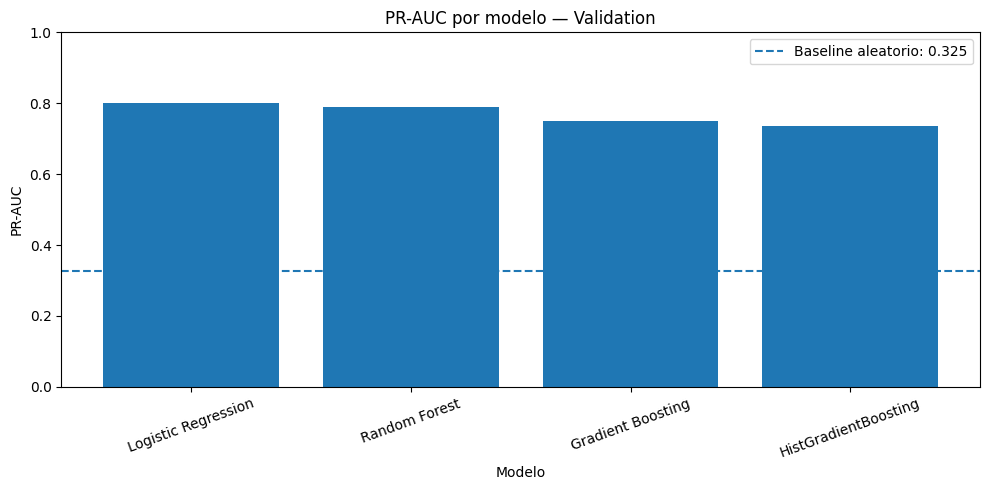

In [24]:
fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.bar(
    validation_comparison["model"],
    validation_comparison["pr_auc"]
)

ax.axhline(
    y_validation.mean(),
    linestyle="--",
    label=(
        "Baseline aleatorio: "
        f"{y_validation.mean():.3f}"
    )
)

ax.set_title(
    "PR-AUC por modelo — Validation"
)

ax.set_ylabel(
    "PR-AUC"
)

ax.set_xlabel(
    "Modelo"
)

ax.set_ylim(
    0,
    1
)

ax.legend()

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### Comparacion ROC-AUC

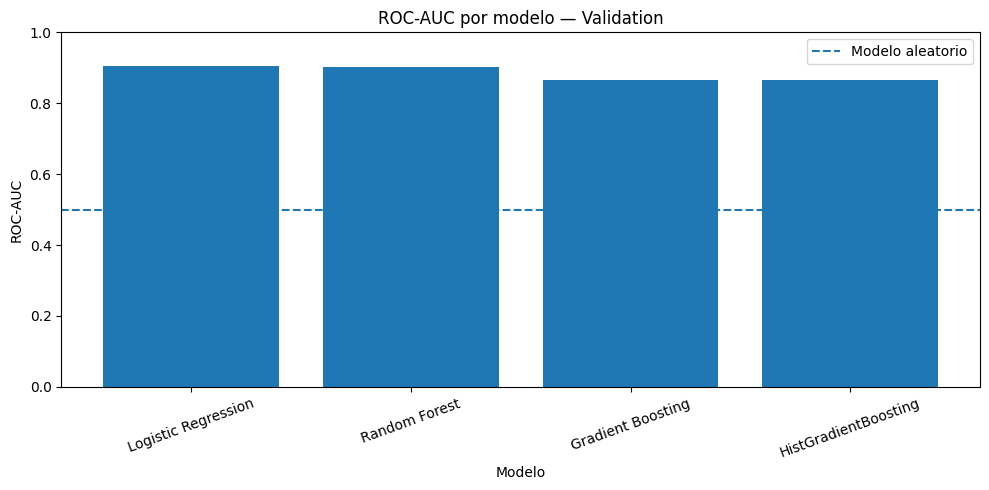

In [25]:
fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.bar(
    validation_comparison["model"],
    validation_comparison["roc_auc"]
)

ax.axhline(
    0.50,
    linestyle="--",
    label="Modelo aleatorio"
)

ax.set_title(
    "ROC-AUC por modelo — Validation"
)

ax.set_ylabel(
    "ROC-AUC"
)

ax.set_xlabel(
    "Modelo"
)

ax.set_ylim(
    0,
    1
)

ax.legend()

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### Train vs Validation

In [26]:
generalization_comparison = (
    model_results[
        [
            "model",
            "train_roc_auc",
            "validation_roc_auc",
            "train_pr_auc",
            "validation_pr_auc",
        ]
    ]
    .copy()
)

generalization_comparison[
    "roc_auc_gap"
] = (
    generalization_comparison[
        "train_roc_auc"
    ]
    -
    generalization_comparison[
        "validation_roc_auc"
    ]
)

generalization_comparison[
    "pr_auc_gap"
] = (
    generalization_comparison[
        "train_pr_auc"
    ]
    -
    generalization_comparison[
        "validation_pr_auc"
    ]
)

generalization_comparison

,model,train_roc_auc,validation_roc_auc,train_pr_auc,validation_pr_auc,roc_auc_gap,pr_auc_gap
0,Logistic Regression,0.867431,0.904387,0.810416,0.801798,-0.036956,0.008618
1,Random Forest,1.000000,0.901249,1.000000,0.788120,0.098751,0.211880
2,Gradient Boosting,0.940324,0.866465,0.916859,0.750238,0.073859,0.166621
3,HistGradientBoosting,0.999708,0.864708,0.999529,0.737073,0.135001,0.262456


## Generalización Train → Validation

Los modelos más complejos tienen mayor capacidad para adaptarse al conjunto de entrenamiento.

Por este motivo no basta con comparar cuál obtiene la métrica más alta en train.

Se calculará la diferencia entre train y validation para:

- ROC-AUC;
- PR-AUC.

Un gap elevado puede indicar sobreajuste.

La selección de candidatos se realizará principalmente a partir del rendimiento sobre validation y de la estabilidad temporal, no del rendimiento sobre train.

## Conclusiones de la comparación inicial de modelos

La comparación inicial muestra que aumentar la complejidad del algoritmo no produce automáticamente una mejora de la capacidad predictiva.

La regresión logística continúa siendo el modelo con mejor rendimiento global sobre validation:

- PR-AUC = 0,802;
- ROC-AUC = 0,904;
- Recall = 0,831;
- F2 = 0,803.

Random Forest obtiene resultados cercanos en discriminación:

- PR-AUC = 0,788;
- ROC-AUC = 0,901.

Además presenta una Precision superior a la regresión logística, pero reduce el Recall hasta aproximadamente el 75 %, lo que implica dejar sin detectar una proporción mayor de retrasos reales.

Los modelos Gradient Boosting e HistGradientBoosting obtienen resultados inferiores al baseline logístico tanto en PR-AUC como en ROC-AUC.

### Generalización

La comparación entre train y validation muestra diferencias importantes entre los algoritmos.

La regresión logística presenta una elevada estabilidad:

- PR-AUC train = 0,810;
- PR-AUC validation = 0,802;
- gap ≈ 0,009.

Por el contrario, Random Forest alcanza un rendimiento perfecto en train:

- PR-AUC train = 1,000;
- PR-AUC validation = 0,788.

Esto indica un claro sobreajuste.

Gradient Boosting e HistGradientBoosting presentan el mismo patrón, con gaps de PR-AUC aproximados de 0,167 y 0,262 respectivamente.

Por tanto, los modelos de árboles evaluados hasta este punto presentan mayor capacidad para ajustarse a los datos históricos, pero peor generalización sobre el período temporal posterior.

### Decisión provisional

La regresión logística continúa siendo el modelo de referencia.

Hasta este punto no existe evidencia de que los modelos no lineales evaluados justifiquen su mayor complejidad.

Random Forest se mantiene como candidato secundario debido a su capacidad de discriminación relativamente cercana al baseline, aunque será necesario controlar su sobreajuste antes de considerarlo como alternativa.

Antes de cerrar la comparación se evaluarán algoritmos de boosting especializados, concretamente XGBoost y LightGBM, que incorporan mecanismos de regularización y optimización diferentes a los modelos de boosting de scikit-learn.

El conjunto de test continúa completamente reservado.

## 5. Boosting especializado — XGBoost y LightGBM

Los primeros modelos basados en árboles no han conseguido superar a la regresión logística.

Además, Random Forest, Gradient Boosting e HistGradientBoosting presentan una diferencia considerable entre el rendimiento de train y validation, lo que indica una mayor tendencia al sobreajuste.

Antes de mantener definitivamente la regresión logística como modelo candidato se evaluarán dos algoritmos especializados en datos tabulares:

- **XGBoost**;
- **LightGBM**.

Ambos pertenecen a la familia Gradient Boosting, pero incorporan mecanismos adicionales de regularización y control de complejidad.

En esta primera comparación no se realizará una búsqueda de hiperparámetros.

Se utilizarán configuraciones conservadoras orientadas a:

- limitar la profundidad de los árboles;
- reducir el learning rate;
- utilizar solo una fracción de observaciones en cada iteración;
- utilizar solo una fracción de variables por árbol;
- incorporar regularización;
- evitar árboles excesivamente específicos.

El objetivo continúa siendo comprobar si existe señal de que estos algoritmos puedan superar de forma estable al baseline logístico.

Se mantendrán:

- las mismas 34 features;
- el mismo train;
- el mismo validation;
- el mismo preprocesamiento de árboles;
- el conjunto de test completamente reservado.

In [27]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import xgboost
import lightgbm

print(
    "XGBoost:",
    xgboost.__version__
)

print(
    "LightGBM:",
    lightgbm.__version__
)

XGBoost: 3.2.0
LightGBM: 4.6.0


### Configuración inicial

Las configuraciones seleccionadas no pretenden ser óptimas.

Su objetivo es establecer una primera comparación razonable controlando el riesgo de sobreajuste observado en los modelos de árboles anteriores.

Se utilizarán árboles relativamente pequeños junto con:

- learning rate reducido;
- subsampling de observaciones;
- subsampling de columnas;
- regularización L1 y L2;
- restricciones sobre el tamaño mínimo de los nodos u hojas.

Si alguno de los modelos supera o se aproxima claramente al baseline logístico con una buena generalización temporal, podrá pasar posteriormente a una fase específica de optimización de hiperparámetros.

Si no existe una mejora relevante, no se realizará tuning únicamente por aumentar la complejidad del proyecto.

### XGBoost

In [28]:
xgboost_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_tree
        ),
        (
            "classifier",
            XGBClassifier(
                n_estimators=300,
                learning_rate=0.03,
                max_depth=3,

                min_child_weight=5,

                subsample=0.80,
                colsample_bytree=0.80,

                reg_alpha=0.10,
                reg_lambda=1.00,

                objective="binary:logistic",
                eval_metric="logloss",

                tree_method="hist",

                random_state=42,
                n_jobs=-1,
            )
        ),
    ]
)

xgboost_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

### LightGBM

In [29]:
lightgbm_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_tree
        ),
        (
            "classifier",
            LGBMClassifier(
                n_estimators=300,
                learning_rate=0.03,

                max_depth=3,
                num_leaves=7,

                min_child_samples=30,

                subsample=0.80,
                subsample_freq=1,
                colsample_bytree=0.80,

                reg_alpha=0.10,
                reg_lambda=1.00,

                objective="binary",

                random_state=42,
                n_jobs=-1,
                verbosity=-1,
            )
        ),
    ]
)

lightgbm_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

### Entrenar modelos

In [30]:
specialized_models = {
    "XGBoost": xgboost_model,
    "LightGBM": lightgbm_model,
}

specialized_results = []

for name, model in specialized_models.items():

    print(
        f"Entrenando: {name}"
    )

    model.fit(
        X_train,
        y_train
    )

    trained_models[name] = model

    train_metrics = (
        evaluate_classifier(
            model,
            X_train,
            y_train,
            "train"
        )
    )

    validation_metrics = (
        evaluate_classifier(
            model,
            X_validation,
            y_validation,
            "validation"
        )
    )

    specialized_results.append({
        "model": name,

        **{
            f"train_{key}": value
            for key, value
            in train_metrics.items()
            if key != "dataset"
        },

        **{
            f"validation_{key}": value
            for key, value
            in validation_metrics.items()
            if key != "dataset"
        },
    })

Entrenando: XGBoost
Entrenando: LightGBM


c:\Users\jesus\OneDrive\Documents\Evolve Data Science\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\jesus\OneDrive\Documents\Evolve Data Science\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\jesus\OneDrive\Documents\Evolve Data Science\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\jesus\OneDrive\Documents\Evolve Data Science\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### Resultados

In [31]:
specialized_results = pd.DataFrame(
    specialized_results
)

specialized_results

,model,train_accuracy,train_balanced_accuracy,train_precision,train_recall,train_f1,train_f2,train_roc_auc,train_pr_auc,validation_accuracy,validation_balanced_accuracy,validation_precision,validation_recall,validation_f1,validation_f2,validation_roc_auc,validation_pr_auc
0,XGBoost,0.836533,0.815590,0.823834,0.727134,0.772470,0.744614,0.916708,0.880679,0.850394,0.818156,0.796460,0.725806,0.759494,0.738916,0.904042,0.790183
1,LightGBM,0.834206,0.813125,0.820380,0.724085,0.769231,0.741492,0.916863,0.881554,0.847769,0.820384,0.779661,0.741935,0.760331,0.749186,0.901406,0.786535


### Unir modelos

In [32]:
all_model_results = pd.concat(
    [
        model_results,
        specialized_results,
    ],
    ignore_index=True,
)

all_model_results

,model,train_accuracy,train_balanced_accuracy,train_precision,train_recall,train_f1,train_f2,train_roc_auc,train_pr_auc,validation_accuracy,validation_balanced_accuracy,validation_precision,validation_recall,validation_f1,validation_f2,validation_roc_auc,validation_pr_auc
0,Logistic Regression,0.788249,0.766627,0.745791,0.675305,0.708800,0.688316,0.867431,0.810416,0.834646,0.833611,0.710345,0.830645,0.765799,0.803432,0.904387,0.801798
1,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.858268,0.830253,0.801724,0.750000,0.775000,0.759804,0.901249,0.788120
2,Gradient Boosting,0.867946,0.846242,0.882353,0.754573,0.813476,0.777080,0.940324,0.916859,0.818898,0.786463,0.735043,0.693548,0.713693,0.701468,0.866465,0.750238
3,HistGradientBoosting,0.989529,0.987740,0.992284,0.980183,0.986196,0.982579,0.999708,0.999529,0.803150,0.768530,0.709402,0.669355,0.688797,0.676998,0.864708,0.737073
4,XGBoost,0.836533,0.815590,0.823834,0.727134,0.772470,0.744614,0.916708,0.880679,0.850394,0.818156,0.796460,0.725806,0.759494,0.738916,0.904042,0.790183
5,LightGBM,0.834206,0.813125,0.820380,0.724085,0.769231,0.741492,0.916863,0.881554,0.847769,0.820384,0.779661,0.741935,0.760331,0.749186,0.901406,0.786535


### Comparacion en validation

In [33]:
all_validation_comparison = (
    all_model_results[
        [
            "model",
            "validation_accuracy",
            "validation_balanced_accuracy",
            "validation_precision",
            "validation_recall",
            "validation_f1",
            "validation_f2",
            "validation_roc_auc",
            "validation_pr_auc",
        ]
    ]
    .copy()
)

all_validation_comparison.columns = [
    "model",
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "f2",
    "roc_auc",
    "pr_auc",
]

all_validation_comparison = (
    all_validation_comparison
    .sort_values(
        "pr_auc",
        ascending=False
    )
    .reset_index(drop=True)
)

all_validation_comparison

,model,accuracy,balanced_accuracy,precision,recall,f1,f2,roc_auc,pr_auc
0,Logistic Regression,0.834646,0.833611,0.710345,0.830645,0.765799,0.803432,0.904387,0.801798
1,XGBoost,0.850394,0.818156,0.796460,0.725806,0.759494,0.738916,0.904042,0.790183
2,Random Forest,0.858268,0.830253,0.801724,0.750000,0.775000,0.759804,0.901249,0.788120
3,LightGBM,0.847769,0.820384,0.779661,0.741935,0.760331,0.749186,0.901406,0.786535
4,Gradient Boosting,0.818898,0.786463,0.735043,0.693548,0.713693,0.701468,0.866465,0.750238
5,HistGradientBoosting,0.803150,0.768530,0.709402,0.669355,0.688797,0.676998,0.864708,0.737073


### Generalizacion de los modelos

In [34]:
all_generalization_comparison = (
    all_model_results[
        [
            "model",
            "train_roc_auc",
            "validation_roc_auc",
            "train_pr_auc",
            "validation_pr_auc",
        ]
    ]
    .copy()
)

all_generalization_comparison[
    "roc_auc_gap"
] = (
    all_generalization_comparison[
        "train_roc_auc"
    ]
    -
    all_generalization_comparison[
        "validation_roc_auc"
    ]
)

all_generalization_comparison[
    "pr_auc_gap"
] = (
    all_generalization_comparison[
        "train_pr_auc"
    ]
    -
    all_generalization_comparison[
        "validation_pr_auc"
    ]
)

all_generalization_comparison = (
    all_generalization_comparison
    .sort_values(
        "validation_pr_auc",
        ascending=False
    )
    .reset_index(drop=True)
)

all_generalization_comparison

,model,train_roc_auc,validation_roc_auc,train_pr_auc,validation_pr_auc,roc_auc_gap,pr_auc_gap
0,Logistic Regression,0.867431,0.904387,0.810416,0.801798,-0.036956,0.008618
1,XGBoost,0.916708,0.904042,0.880679,0.790183,0.012667,0.090496
2,Random Forest,1.000000,0.901249,1.000000,0.788120,0.098751,0.211880
3,LightGBM,0.916863,0.901406,0.881554,0.786535,0.015457,0.095019
4,Gradient Boosting,0.940324,0.866465,0.916859,0.750238,0.073859,0.166621
5,HistGradientBoosting,0.999708,0.864708,0.999529,0.737073,0.135001,0.262456


### PR-AUC modelos

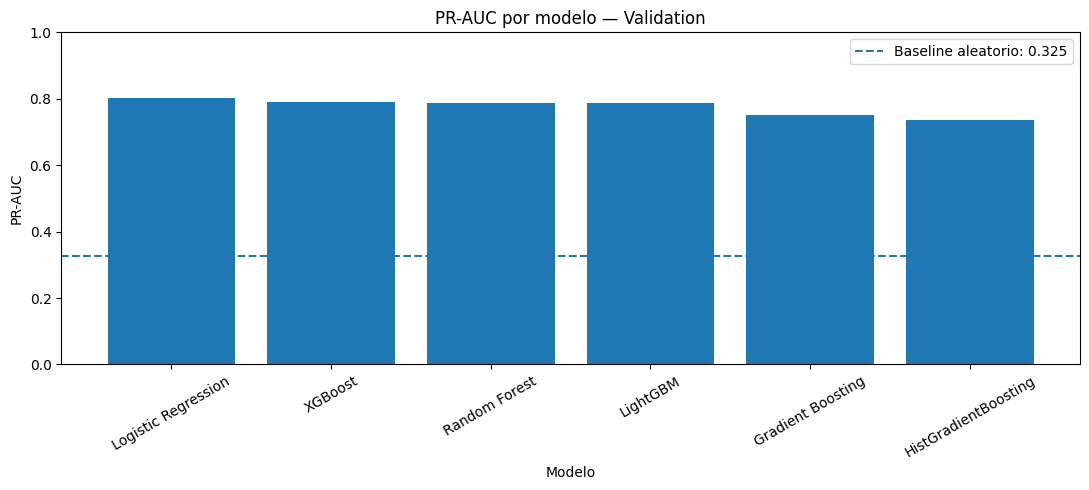

In [35]:
fig, ax = plt.subplots(
    figsize=(11, 5)
)

ax.bar(
    all_validation_comparison[
        "model"
    ],
    all_validation_comparison[
        "pr_auc"
    ]
)

ax.axhline(
    y_validation.mean(),
    linestyle="--",
    label=(
        "Baseline aleatorio: "
        f"{y_validation.mean():.3f}"
    )
)

ax.set_title(
    "PR-AUC por modelo — Validation"
)

ax.set_xlabel(
    "Modelo"
)

ax.set_ylabel(
    "PR-AUC"
)

ax.set_ylim(
    0,
    1
)

ax.legend()

plt.xticks(
    rotation=30
)

plt.tight_layout()
plt.show()

### ROC-AUC modelos

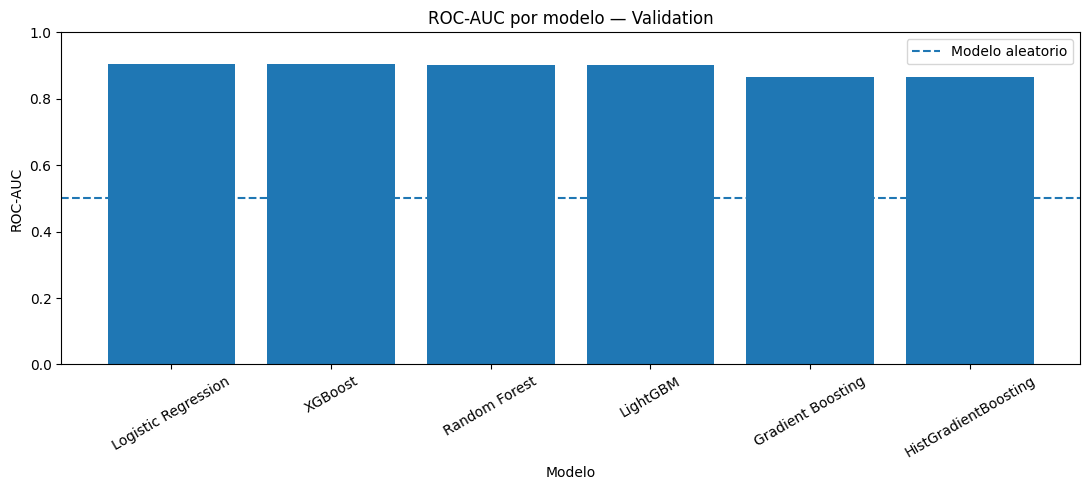

In [36]:
fig, ax = plt.subplots(
    figsize=(11, 5)
)

ax.bar(
    all_validation_comparison[
        "model"
    ],
    all_validation_comparison[
        "roc_auc"
    ]
)

ax.axhline(
    0.50,
    linestyle="--",
    label="Modelo aleatorio"
)

ax.set_title(
    "ROC-AUC por modelo — Validation"
)

ax.set_xlabel(
    "Modelo"
)

ax.set_ylabel(
    "ROC-AUC"
)

ax.set_ylim(
    0,
    1
)

ax.legend()

plt.xticks(
    rotation=30
)

plt.tight_layout()
plt.show()

### Gap de PR-AUC

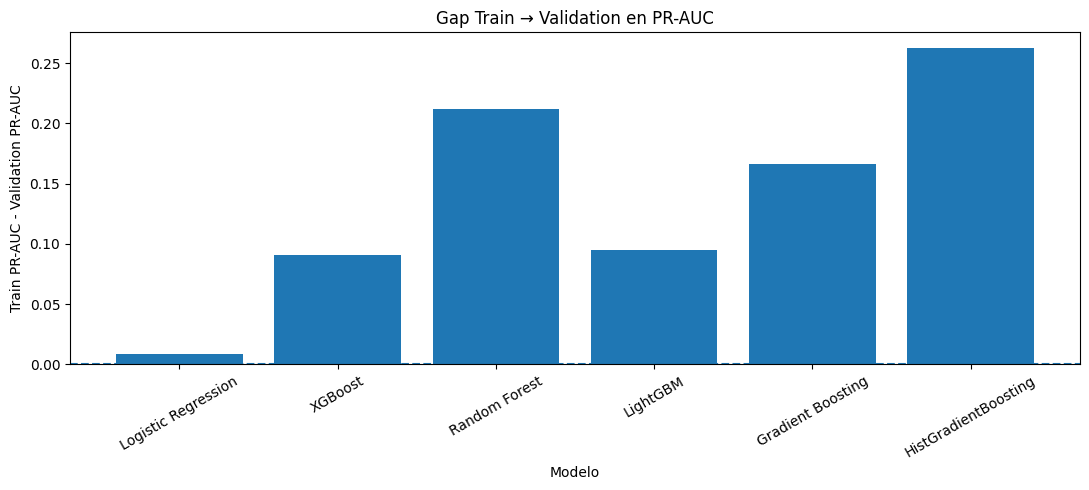

In [37]:
fig, ax = plt.subplots(
    figsize=(11, 5)
)

ax.bar(
    all_generalization_comparison[
        "model"
    ],
    all_generalization_comparison[
        "pr_auc_gap"
    ]
)

ax.axhline(
    0,
    linestyle="--"
)

ax.set_title(
    "Gap Train → Validation en PR-AUC"
)

ax.set_xlabel(
    "Modelo"
)

ax.set_ylabel(
    "Train PR-AUC - Validation PR-AUC"
)

plt.xticks(
    rotation=30
)

plt.tight_layout()
plt.show()

## Criterio para seleccionar modelos candidatos

La selección no se realizará utilizando únicamente la métrica más alta.

Se considerarán conjuntamente:

1. **PR-AUC en validation**
   - métrica principal para comparar capacidad predictiva sobre la clase positiva.

2. **ROC-AUC en validation**
   - capacidad global de discriminación.

3. **Gap Train → Validation**
   - indicador de estabilidad y posible sobreajuste.

4. **Recall y F2**
   - comportamiento inicial con threshold 0,50.

5. **Complejidad**
   - un modelo complejo deberá aportar una mejora suficiente para justificar una menor interpretabilidad y un pipeline más difícil de mantener.

Se considerará candidato a tuning un modelo complejo únicamente si:

- supera claramente a la regresión logística;
- o queda suficientemente cerca y existe evidencia de que una regularización o ajuste razonable puede mejorar su generalización.

Una mejora mínima de unas pocas milésimas en PR-AUC no se considerará por sí sola suficiente para sustituir a un baseline más simple e interpretable.

El conjunto de test continuará completamente reservado.

### Diferencia respecto a Logistic

In [38]:
logistic_reference = (
    all_validation_comparison
    .loc[
        all_validation_comparison[
            "model"
        ]
        == "Logistic Regression",
        [
            "roc_auc",
            "pr_auc",
        ]
    ]
    .iloc[0]
)

model_improvement = (
    all_validation_comparison[
        [
            "model",
            "roc_auc",
            "pr_auc",
        ]
    ]
    .copy()
)

model_improvement[
    "delta_roc_auc_vs_logistic"
] = (
    model_improvement[
        "roc_auc"
    ]
    -
    logistic_reference[
        "roc_auc"
    ]
)

model_improvement[
    "delta_pr_auc_vs_logistic"
] = (
    model_improvement[
        "pr_auc"
    ]
    -
    logistic_reference[
        "pr_auc"
    ]
)

model_improvement

,model,roc_auc,pr_auc,delta_roc_auc_vs_logistic,delta_pr_auc_vs_logistic
0,Logistic Regression,0.904387,0.801798,0.000000,0.000000
1,XGBoost,0.904042,0.790183,-0.000345,-0.011615
2,Random Forest,0.901249,0.788120,-0.003138,-0.013678
3,LightGBM,0.901406,0.786535,-0.002981,-0.015263
4,Gradient Boosting,0.866465,0.750238,-0.037922,-0.051560
5,HistGradientBoosting,0.864708,0.737073,-0.039679,-0.064725


# Conclusiones finales de la comparación de modelos

El objetivo de este notebook era determinar si algoritmos de mayor complejidad podían mejorar de forma suficientemente relevante el rendimiento de la regresión logística seleccionada como baseline.

Todos los modelos se han evaluado utilizando:

- las mismas 34 features del Modelo C;
- el mismo conjunto de train;
- el mismo conjunto de validation;
- el mismo split temporal;
- el conjunto de test completamente reservado.

Se han comparado seis algoritmos:

1. Logistic Regression;
2. Random Forest;
3. Gradient Boosting;
4. HistGradientBoosting;
5. XGBoost;
6. LightGBM.

## Resultados sobre validation

La regresión logística continúa presentando el mejor rendimiento global para el objetivo del proyecto.

Obtiene aproximadamente:

- PR-AUC = 0,802;
- ROC-AUC = 0,904;
- Recall = 0,831;
- Precision = 0,710;
- F2 = 0,803.

Estos resultados constituyen la referencia frente a la que se han evaluado los modelos de mayor complejidad.

## Random Forest

Random Forest alcanza:

- PR-AUC = 0,788;
- ROC-AUC = 0,901;
- Precision = 0,802;
- Recall = 0,750;
- F2 = 0,760.

Aunque presenta una Precision superior a la regresión logística, detecta una proporción menor de retrasos reales.

Además, alcanza un rendimiento perfecto sobre train:

- PR-AUC train = 1,000;
- ROC-AUC train = 1,000.

El gap de PR-AUC entre train y validation es aproximadamente 0,212, lo que indica un sobreajuste considerable.

Por estos motivos no se considera una alternativa superior al baseline.

## Gradient Boosting

Gradient Boosting obtiene:

- PR-AUC = 0,750;
- ROC-AUC = 0,866;
- Recall = 0,694;
- F2 = 0,701.

El rendimiento es claramente inferior al de la regresión logística y presenta además un gap de PR-AUC de aproximadamente 0,167.

No se considera candidato para fases posteriores.

## HistGradientBoosting

HistGradientBoosting obtiene:

- PR-AUC = 0,737;
- ROC-AUC = 0,865;
- Recall = 0,669;
- F2 = 0,677.

También alcanza un rendimiento prácticamente perfecto sobre train, con un gap de PR-AUC de aproximadamente 0,262.

Es el modelo con mayor evidencia de sobreajuste entre los algoritmos evaluados y queda descartado como candidato.

## XGBoost

XGBoost es el modelo complejo que más se aproxima a la regresión logística.

Obtiene:

- PR-AUC = 0,790;
- ROC-AUC = 0,904;
- Precision = 0,796;
- Recall = 0,726;
- F2 = 0,739.

Su ROC-AUC es prácticamente equivalente al de la regresión logística:

`0,9040 frente a 0,9044`

Sin embargo, PR-AUC es inferior:

`0,790 frente a 0,802`

y el Recall con threshold 0,50 también disminuye de forma apreciable.

Además, presenta:

- PR-AUC train = 0,881;
- PR-AUC validation = 0,790;
- gap ≈ 0,090.

La configuración regularizada reduce considerablemente el sobreajuste observado en otros modelos de árboles, pero todavía no consigue superar al baseline lineal.

Por tanto, no existe evidencia suficiente para justificar una fase adicional de tuning.

## LightGBM

LightGBM presenta un comportamiento similar a XGBoost:

- PR-AUC = 0,787;
- ROC-AUC = 0,901;
- Precision = 0,780;
- Recall = 0,742;
- F2 = 0,749.

El gap entre train y validation en PR-AUC es aproximadamente 0,095.

Aunque generaliza mejor que Random Forest, Gradient Boosting e HistGradientBoosting, no consigue mejorar la regresión logística.

Tampoco se considera necesario realizar una búsqueda adicional de hiperparámetros.

## Complejidad frente a rendimiento

Los resultados muestran que aumentar la capacidad del algoritmo no produce una mejora del rendimiento sobre datos futuros.

La regresión logística presenta simultáneamente:

- el mejor PR-AUC;
- el mejor ROC-AUC, prácticamente empatado con XGBoost;
- el mayor Recall con threshold 0,50;
- el mayor F2;
- el menor gap entre train y validation;
- mayor interpretabilidad;
- menor complejidad operativa.

Por tanto, los modelos complejos no aportan una mejora suficiente para compensar:

- mayor coste de entrenamiento;
- mayor número de hiperparámetros;
- menor interpretabilidad;
- mayor riesgo de sobreajuste;
- mayor complejidad de mantenimiento.

## Decisión sobre tuning

No se realizará tuning de Random Forest, Gradient Boosting, HistGradientBoosting, XGBoost o LightGBM.

Esta decisión no implica que estos algoritmos sean menos adecuados de forma general, sino que con el tamaño, las features y el período temporal disponibles en este proyecto no muestran una ventaja sobre la regresión logística.

Realizar una búsqueda extensa de hiperparámetros sin evidencia previa de mejora aumentaría el riesgo de sobreoptimizar el conjunto de validation.

## Modelo seleccionado

Se mantiene como modelo candidato final:

**Logistic Regression — Modelo C**

con:

- 34 features;
- preprocesamiento mediante imputación, escalado y One-Hot Encoding;
- histórico del comportamiento de pago como principal fuente predictiva.

El threshold operativo provisional seleccionado durante el notebook de baseline continúa siendo:

`threshold = 0.40`

Este punto permite mantener aproximadamente un Recall superior al 90 % en validation con un compromiso razonable entre retrasos detectados y falsas alarmas.

## Generalización temporal

Uno de los resultados más favorables de la regresión logística es su estabilidad entre train y validation.

El gap de PR-AUC es aproximadamente:

`0,009`

frente a valores considerablemente superiores en todos los modelos de árboles evaluados.

Esto refuerza la elección de un modelo más sencillo en un dataset relativamente pequeño y con evaluación temporal.

## Veredicto

La comparación de modelos se considera finalizada.

No se ha encontrado ningún algoritmo de mayor complejidad que supere de forma relevante a la regresión logística.

La regresión logística Modelo C se selecciona como **modelo final candidato** por combinar:

- elevada capacidad predictiva;
- buena generalización temporal;
- Recall elevado;
- interpretabilidad;
- menor complejidad.

El conjunto de test continúa completamente reservado y no ha intervenido en ninguna decisión de selección del modelo.

La siguiente fase deberá comprobar, antes de abrir test, si las probabilidades producidas por el modelo están adecuadamente calibradas.

Después de cerrar la estrategia de calibración, el modelo y el threshold quedarán congelados y se realizará una única evaluación final sobre test.